# Day 4 -- Transfer Learning: Standing on the Shoulders of Giants

Yesterday's CNN trained on 60,000 images. Real engineering and field datasets are rarely that
generous -- a crack-detection dataset might have a few hundred labeled photos, not tens of
thousands. Today: **transfer learning**, the standard technique for getting strong results from
a small dataset by reusing a network someone else already trained on millions of images.

**Setup note**: today's demo downloads two small things the first time it runs -- a real-photo
dataset (~11 MB) and a pretrained model's weights (~14 MB). Both are small enough to download in
seconds on a normal connection.
*(Once downloaded, Keras stores both in a folder called `.keras` on your computer and reuses that
cached copy every time after that -- so if you've already run this notebook before, nothing will
re-download; it will just load instantly from disk.)*

## Hook (10 min)

Run the cell below. It downloads a small, real-world image dataset: 256 color photos, 300x300
pixels, split evenly between two classes -- **horse** and **human**. That's roughly what a small
real-world engineering image dataset might look like: a couple hundred labeled photos, not tens
of thousands.

11480187/11480187 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Loaded 256 images total: 128 horses, 128 humans


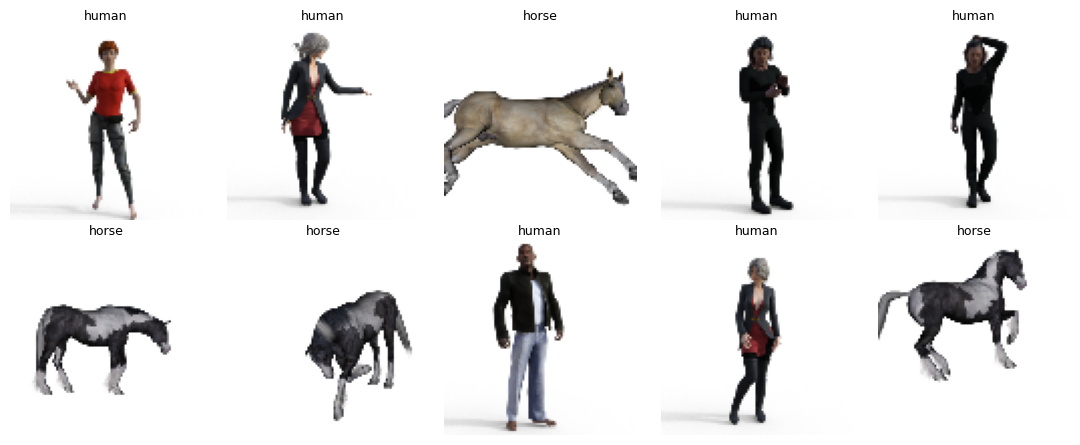

Training images: 204
Test images: 52
This is a MUCH smaller dataset than yesterday's 60,000 Fashion-MNIST images.


In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pathlib
import zipfile

# Step 1: Download the dataset. This is a small, real dataset of 300x300 color photos --
# 128 horse photos and 128 human photos (256 total, about 11 MB). Once downloaded, Keras
# caches it in a folder called `.keras` and reuses that copy every time after this, so
# re-running this cell later won't re-download anything.
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/validation-horse-or-human.zip"
zip_path = keras.utils.get_file(fname="horse-or-human.zip", origin=dataset_url)

# Step 2: Unzip it (only if we haven't already) into its own folder next to the download.
extract_dir = pathlib.Path(zip_path).parent / "horse-or-human"
if not extract_dir.exists():
    with zipfile.ZipFile(zip_path) as zip_file:
        zip_file.extractall(extract_dir)

# Step 3: Load every image into a numpy array, resizing each to 96x96 -- a size MobileNetV2
# (the pretrained model we'll use later today) expects.
IMG_SIZE = 96
class_names = ["horse", "human"]


def load_class_images(folder, label):
    """Load every image in `folder`, resized to IMG_SIZE x IMG_SIZE, all labeled `label`."""
    images = []
    for file_path in sorted(folder.glob("*.png")):
        image = keras.utils.load_img(file_path, target_size=(IMG_SIZE, IMG_SIZE))
        images.append(keras.utils.img_to_array(image))
    labels = np.full(len(images), label)
    return np.array(images), labels


horse_images, horse_labels = load_class_images(extract_dir / "horses", label=0)
human_images, human_labels = load_class_images(extract_dir / "humans", label=1)

all_images = np.concatenate([horse_images, human_images], axis=0)
all_labels = np.concatenate([horse_labels, human_labels], axis=0)

print("Loaded", len(all_images), "images total:", len(horse_images), "horses,", len(human_images), "humans")

# Step 4: Split into train and test sets, 80% / 20%, keeping the two classes balanced in each
# split (shuffle each class separately before splitting, so we don't accidentally put more
# horses than humans into the test set).
np.random.seed(0)  # makes the "random" choices below the same every time we run this


def split_train_test(images, labels, train_fraction=0.8):
    train_images, train_labels, test_images, test_labels = [], [], [], []
    for class_number in np.unique(labels):
        class_indexes = np.where(labels == class_number)[0]
        class_indexes = np.random.permutation(class_indexes)
        n_train = int(len(class_indexes) * train_fraction)
        train_images.append(images[class_indexes[:n_train]])
        train_labels.append(labels[class_indexes[:n_train]])
        test_images.append(images[class_indexes[n_train:]])
        test_labels.append(labels[class_indexes[n_train:]])

    x_train = np.concatenate(train_images, axis=0)
    y_train = np.concatenate(train_labels, axis=0)
    x_test = np.concatenate(test_images, axis=0)
    y_test = np.concatenate(test_labels, axis=0)

    # Shuffle again so the two classes are mixed together, not in two separate blocks.
    # (This matters later: Keras takes its validation data from the END of the array, so if
    # the classes were still in blocks, validation could end up with only one class in it.)
    train_shuffle = np.random.permutation(len(y_train))
    test_shuffle = np.random.permutation(len(y_test))
    return x_train[train_shuffle], y_train[train_shuffle], x_test[test_shuffle], y_test[test_shuffle]


x_train_small, y_train_small, x_test_small, y_test_small = split_train_test(all_images, all_labels)

# Show 10 example training images with their class names.
fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train_small[i].astype("uint8"))
    ax.set_title(class_names[y_train_small[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Training images:", len(x_train_small))
print("Test images:", len(x_test_small))
print("This is a MUCH smaller dataset than yesterday's 60,000 Fashion-MNIST images.")

## Concept (25 min)

### Why "from scratch" struggles with small data

A CNN like yesterday's has tens of thousands of parameters, all initialized randomly and
learned purely from the training images you give it. With only a couple hundred training images
spread across 2 classes, a from-scratch CNN doesn't see nearly enough examples to learn general,
reliable features -- it tends to either underfit (never really learns the classes) or overfit
(memorizes the specific training photos) rather than generalizing.

### Pretrained models and ImageNet

**MobileNetV2** is a CNN architecture that has already been trained on **ImageNet** -- roughly
1.4 million photos across 1,000 everyday object categories. In the process, its early and
middle layers learned to detect edges, textures, colors, and shape parts that are useful for
recognizing almost *any* natural image, not just the original 1,000 classes. We can reuse those
already-learned features instead of relearning them from a couple hundred images.

### Feature extraction vs. fine-tuning

Two ways to reuse a pretrained model:

| Approach | What happens | When to use |
| --- | --- | --- |
| **Feature extraction** | Freeze (don't update) all of the pretrained model's weights. Add a small new "head" (a few Dense layers) on top, and train *only* the head on your data. | Your dataset is small and/or similar to natural photos -- the pretrained features are probably already good enough. |
| **Fine-tuning** | After feature extraction, unfreeze the last several layers of the pretrained model too, and continue training everything with a *very small* learning rate. | You have a bit more data, or your images are different enough from ImageNet that the pretrained top layers need slight adjustment. |

Fine-tuning uses a tiny learning rate deliberately: the pretrained weights are already good, and
a normal-sized learning rate would wreck them in a few batches -- the equivalent of demolishing
a mostly-finished building to fix one crack.

### Data augmentation

With only about 100 training images per class, we can synthetically grow the effective dataset
size by applying small random transformations (flip, rotation, zoom) to each image every time
it's seen during training -- the network never sees the *exact* same image pixel-for-pixel twice,
which reduces overfitting the way Dropout did on Day 2, but by varying the data instead of the
network.

## Part A -- Instructor-Led Demo

### Guided Demo, Part 1 (40 min) -- A from-scratch baseline, then augmentation + pretrained base

In [2]:
# Baseline: a from-scratch CNN, same style as Day 3, trained on this tiny image dataset.
scratch_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),  #Dense layer with nonlinearity of features
    keras.layers.Dense(2, activation="softmax"), #Output Layer
])

# Scale pixel values from the 0-255 range down to 0-1, which networks train better on.
x_train_small_norm = x_train_small.astype("float32") / 255.0
x_test_small_norm = x_test_small.astype("float32") / 255.0

scratch_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

scratch_history = scratch_model.fit(
    x_train_small_norm, y_train_small,
    epochs=15, batch_size=32, validation_split=0.15, verbose=0,
)

scratch_test_loss, scratch_test_acc = scratch_model.evaluate(x_test_small_norm, y_test_small, verbose=0)
print("From-scratch CNN test accuracy:", round(scratch_test_acc, 4))
print("Keep this number -- we'll beat it with transfer learning below.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


From-scratch CNN test accuracy: 0.9231
Keep this number -- we'll beat it with transfer learning below.


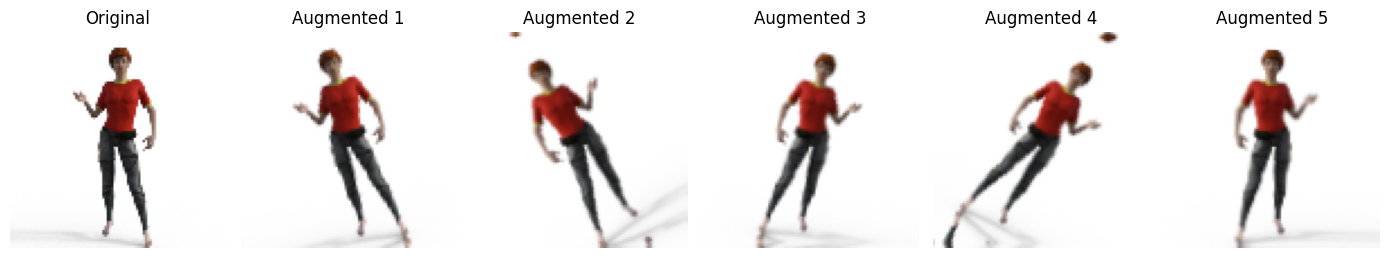

In [4]:
# Data augmentation, expressed as ordinary Keras layers -- only active during training.
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
])

# Preview: apply augmentation to the SAME image 5 times, to see what it does.
sample_image = x_train_small_norm[0:1]  # a "batch" containing just 1 image

fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
axes[0].imshow(sample_image[0])
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(1, 6):
    augmented_image = data_augmentation(sample_image, training=True)
    axes[i].imshow(augmented_image[0].numpy())
    axes[i].set_title("Augmented " + str(i))
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# MobileNetV2's own preprocessing scales pixel values to the range it was trained on
# (roughly -1 to 1), which is different from the simple /255 we used for the scratch model.
x_train_pre = keras.applications.mobilenet_v2.preprocess_input(x_train_small.copy())
x_test_pre = keras.applications.mobilenet_v2.preprocess_input(x_test_small.copy())

# Load MobileNetV2, already trained on 1.4 million ImageNet photos.
# weights="imagenet" downloads the pretrained weights ONE TIME (~14 MB) and then
# reuses the cached copy after that -- if you've already run this before, it
# will NOT download again, it will just load from disk.
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,        # drop MobileNet's original 1000-class ImageNet head
    weights="imagenet",
)
base_model.trainable = False   # freeze -- feature extraction, not fine-tuning, for now

transfer_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    data_augmentation,
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(2, activation="softmax"),
])

transfer_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Look at the summary: most of the parameters are in `mobilenetv2_...` and are marked
non-trainable -- we are not updating any of them yet. Only the small new head (Dense layers) at
the end is trainable, which is why this stage of training is fast even though the full network
is deep.

**Break (10 min)**

### Guided Demo, Part 2 (30 min) -- Train, compare, then fine-tune

In [6]:
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

feature_extraction_history = transfer_model.fit(
    x_train_pre, y_train_small,
    epochs=15,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1,
)

fe_test_loss, fe_test_acc = transfer_model.evaluate(x_test_pre, y_test_small, verbose=0)
print("Transfer learning (feature extraction) test accuracy:", round(fe_test_acc, 4))
print("From-scratch CNN test accuracy (same images):        ", round(scratch_test_acc, 4))

Epoch 1/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 824ms/step - accuracy: 0.6012 - loss: 0.9741 - val_accuracy: 0.8710 - val_loss: 0.3087
Epoch 2/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step - accuracy: 0.8902 - loss: 0.2366 - val_accuracy: 1.0000 - val_loss: 0.0861
Epoch 3/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - accuracy: 0.9769 - loss: 0.0860 - val_accuracy: 1.0000 - val_loss: 0.0362
Epoch 4/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 322ms/step - accuracy: 0.9884 - loss: 0.0391 - val_accuracy: 1.0000 - val_loss: 0.0217
Epoch 5/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - accuracy: 0.9942 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0160
Epoch 6/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 342ms/step - accuracy: 0.9942 - loss: 0.0208 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 7/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 557ms/step - accuracy: 0.9942 - loss: 0.0196 - val_accuracy: 1.0000 - val_loss: 0.0113
Epoch 8/15
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 316ms/step - accuracy: 1.0000 - loss: 0.0118 - val_accuracy: 1.0000 - val_loss

On this tiny dataset, transfer learning should noticeably beat the from-scratch CNN -- it isn't
starting from random weights, so it doesn't need nearly as many examples to reach a good
decision boundary.

In [7]:
# Fine-tuning: unfreeze the LAST 20 layers of the pretrained base and continue training
# everything together, with a much smaller learning rate than the default.
base_model.trainable = True

layers_to_unfreeze = 20
total_layers = len(base_model.layers)
first_unfrozen_index = total_layers - layers_to_unfreeze

for i, layer in enumerate(base_model.layers):
    if i < first_unfrozen_index:
        layer.trainable = False   # keep this early layer frozen
    else:
        layer.trainable = True    # this is one of the last 20 layers -- unfreeze it

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),   # note: 100x smaller than the default 1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = transfer_model.fit(
    x_train_pre, y_train_small,
    epochs=10,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1,
)

ft_test_loss, ft_test_acc = transfer_model.evaluate(x_test_pre, y_test_small, verbose=0)

comparison = pd.DataFrame({
    "approach": ["From-scratch CNN", "Transfer learning (frozen base)", "Transfer learning (fine-tuned)"],
    "test_accuracy": [scratch_test_acc, fe_test_acc, ft_test_acc],
})
comparison

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.9653 - loss: 0.1093 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 406ms/step - accuracy: 0.9711 - loss: 0.0897 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 403ms/step - accuracy: 0.9827 - loss: 0.0581 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 402ms/step - accuracy: 0.9769 - loss: 0.0609 - val_accuracy: 1.0000 - val_loss: 0.0032
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 656ms/step - accuracy: 0.9942 - loss: 0.0590 - val_accuracy: 1.0000 - val_loss: 0.0028
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step - accuracy: 1.0000 - loss: 0.0235 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 419ms/step - accuracy: 0.9884 - loss: 0.0297 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 1.0000 - loss: 0.0206 - val_accuracy: 1.0000 - val_loss: 0

,approach,test_accuracy
0,From-scratch CNN,0.923077
1,Transfer learning (frozen base),1.000000
2,Transfer learning (fine-tuned),1.000000


Fine-tuning usually gives a further small-to-moderate boost over feature extraction alone --
but it can also make things worse if the learning rate is too high or too many layers are
unfrozen with too little data, since that risks damaging the pretrained weights you're relying
on. This is exactly why the learning rate above is deliberately tiny.

## Part B -- Your Turn (Short Assignment, ~30-40 min)

In [ ]:
# TODO 1: Change the augmentation pipeline.
# Rebuild `data_augmentation` WITHOUT RandomZoom (keep RandomFlip and RandomRotation), retrain
# a fresh feature-extraction transfer model (frozen base) from scratch, and compare test
# accuracy to the demo's full-augmentation version.

# YOUR CODE HERE

**Your answer (TODO 1)**: Did removing RandomZoom change test accuracy or the train/validation
gap? *(Write 2-3 sentences here.)*

In [ ]:
# TODO 2: Unfreeze a different number of layers.
# Starting again from the frozen feature-extraction model, fine-tune with the LAST 40 layers
# unfrozen instead of 20 (same tiny learning rate 1e-5). Compare test accuracy to the demo's
# 20-layer fine-tuning result.

# YOUR CODE HERE

**Your answer (TODO 2)**: Did unfreezing more layers help, hurt, or make little difference on
this small dataset? What does that suggest about matching how much you unfreeze to how much
data you have? *(Write 2-3 sentences here.)*

---

## What's next

Tomorrow is the capstone: you'll pick a track (from-scratch CNN or transfer learning) and apply
this week's full pipeline -- data prep, training, evaluation, and comparison to a classical ML
baseline -- to a dataset of your own.